# 07 — K-Means Student Clustering

**Project:** MARS — Multi-Agent Recommender System for Personalized Learning  
**Agent:** PersonalizationAgent  
**Purpose:** Cluster students into learner archetypes using K-Means on
8 behavioural features.  Select optimal K via Silhouette Score and
generate paper figures (elbow, t-SNE, radar, box plots).

In [1]:
import sys
sys.path.insert(0, "..")

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

plt.style.use("seaborn-v0_8-paper")
plt.rcParams.update({
    "figure.dpi": 300, "savefig.dpi": 300,
    "font.size": 11, "axes.titlesize": 13,
    "axes.labelsize": 12, "figure.figsize": (8, 5),
    "savefig.bbox": "tight",
})

RESULTS_DIR = Path("../results")
RESULTS_DIR.mkdir(exist_ok=True)

import logging
logging.basicConfig(level=logging.INFO, format="%(name)s | %(message)s")

print("Libraries loaded.")

Libraries loaded.


## 1. Load Data & Extract Features

In [2]:
from data.loader import EdNetLoader
from agents.personalization_agent import (
    PersonalizationAgent, extract_user_features,
    FEATURE_NAMES, FEATURE_NAMES_SCALAR, FEATURE_NAMES_ONEHOT,
    ClusterProfile, K_RANGE,
)

loader = EdNetLoader(data_dir="../data/raw")
interactions = loader.load_interactions(sample_users=1000)
print(f"Interactions: {len(interactions):,} ({interactions['user_id'].nunique()} users)")

# Extract features
user_features = extract_user_features(interactions)
print(f"\nUser features shape: {user_features.shape}")
print(f"Features: {FEATURE_NAMES}")
user_features.describe().round(3)

faiss.loader | Loading faiss with AVX2 support.


faiss.loader | Successfully loaded faiss with AVX2 support.


data.loader | Loading questions from ..\data\raw\questions.csv


data.loader | Loaded 13169 questions, 189 unique tags


data.loader | Found 297444 user files in KT2/


...

Interactions: 51,802 (998 users)


2026-04-02 18:05:41 | mars.agent.personalization     | INFO    | Extracted features for 998 users (14 dimensions)


mars.agent.personalization | Extracted features for 998 users (14 dimensions)



User features shape: (998, 14)
Features: ['avg_elapsed_time', 'accuracy_rate', 'changed_answer_rate', 'session_frequency', 'avg_questions_per_session', 'false_confidence_rate', 'learning_speed', 'dominant_part_1', 'dominant_part_2', 'dominant_part_3', 'dominant_part_4', 'dominant_part_5', 'dominant_part_6', 'dominant_part_7']


,avg_elapsed_time,accuracy_rate,changed_answer_rate,session_frequency,avg_questions_per_session,false_confidence_rate,learning_speed,dominant_part_1,dominant_part_2,dominant_part_3,dominant_part_4,dominant_part_5,dominant_part_6,dominant_part_7
count,998.000,998.000,998.000,998.000,998.000,998.000,998.000,998.000,998.000,998.000,998.000,998.000,998.0,998.000
mean,1.281,0.502,0.117,1.620,9.243,0.180,-0.000,0.037,0.113,0.003,0.001,0.844,0.0,0.002
std,0.610,0.219,0.159,2.108,7.457,0.180,0.021,0.189,0.317,0.055,0.032,0.363,0.0,0.045
min,0.202,0.000,0.000,0.039,1.000,0.000,-0.127,0.000,0.000,0.000,0.000,0.000,0.0,0.000
25%,0.943,0.364,0.000,1.000,6.000,0.004,0.000,0.000,0.000,0.000,0.000,1.000,0.0,0.000
50%,1.172,0.500,0.077,1.000,7.000,0.143,0.000,0.000,0.000,0.000,0.000,1.000,0.0,0.000
75%,1.457,0.659,0.167,1.000,10.000,0.267,0.000,0.000,0.000,0.000,0.000,1.000,0.0,0.000
max,10.000,1.000,1.000,23.000,87.000,1.000,0.145,1.000,1.000,1.000,1.000,1.000,0.0,1.000


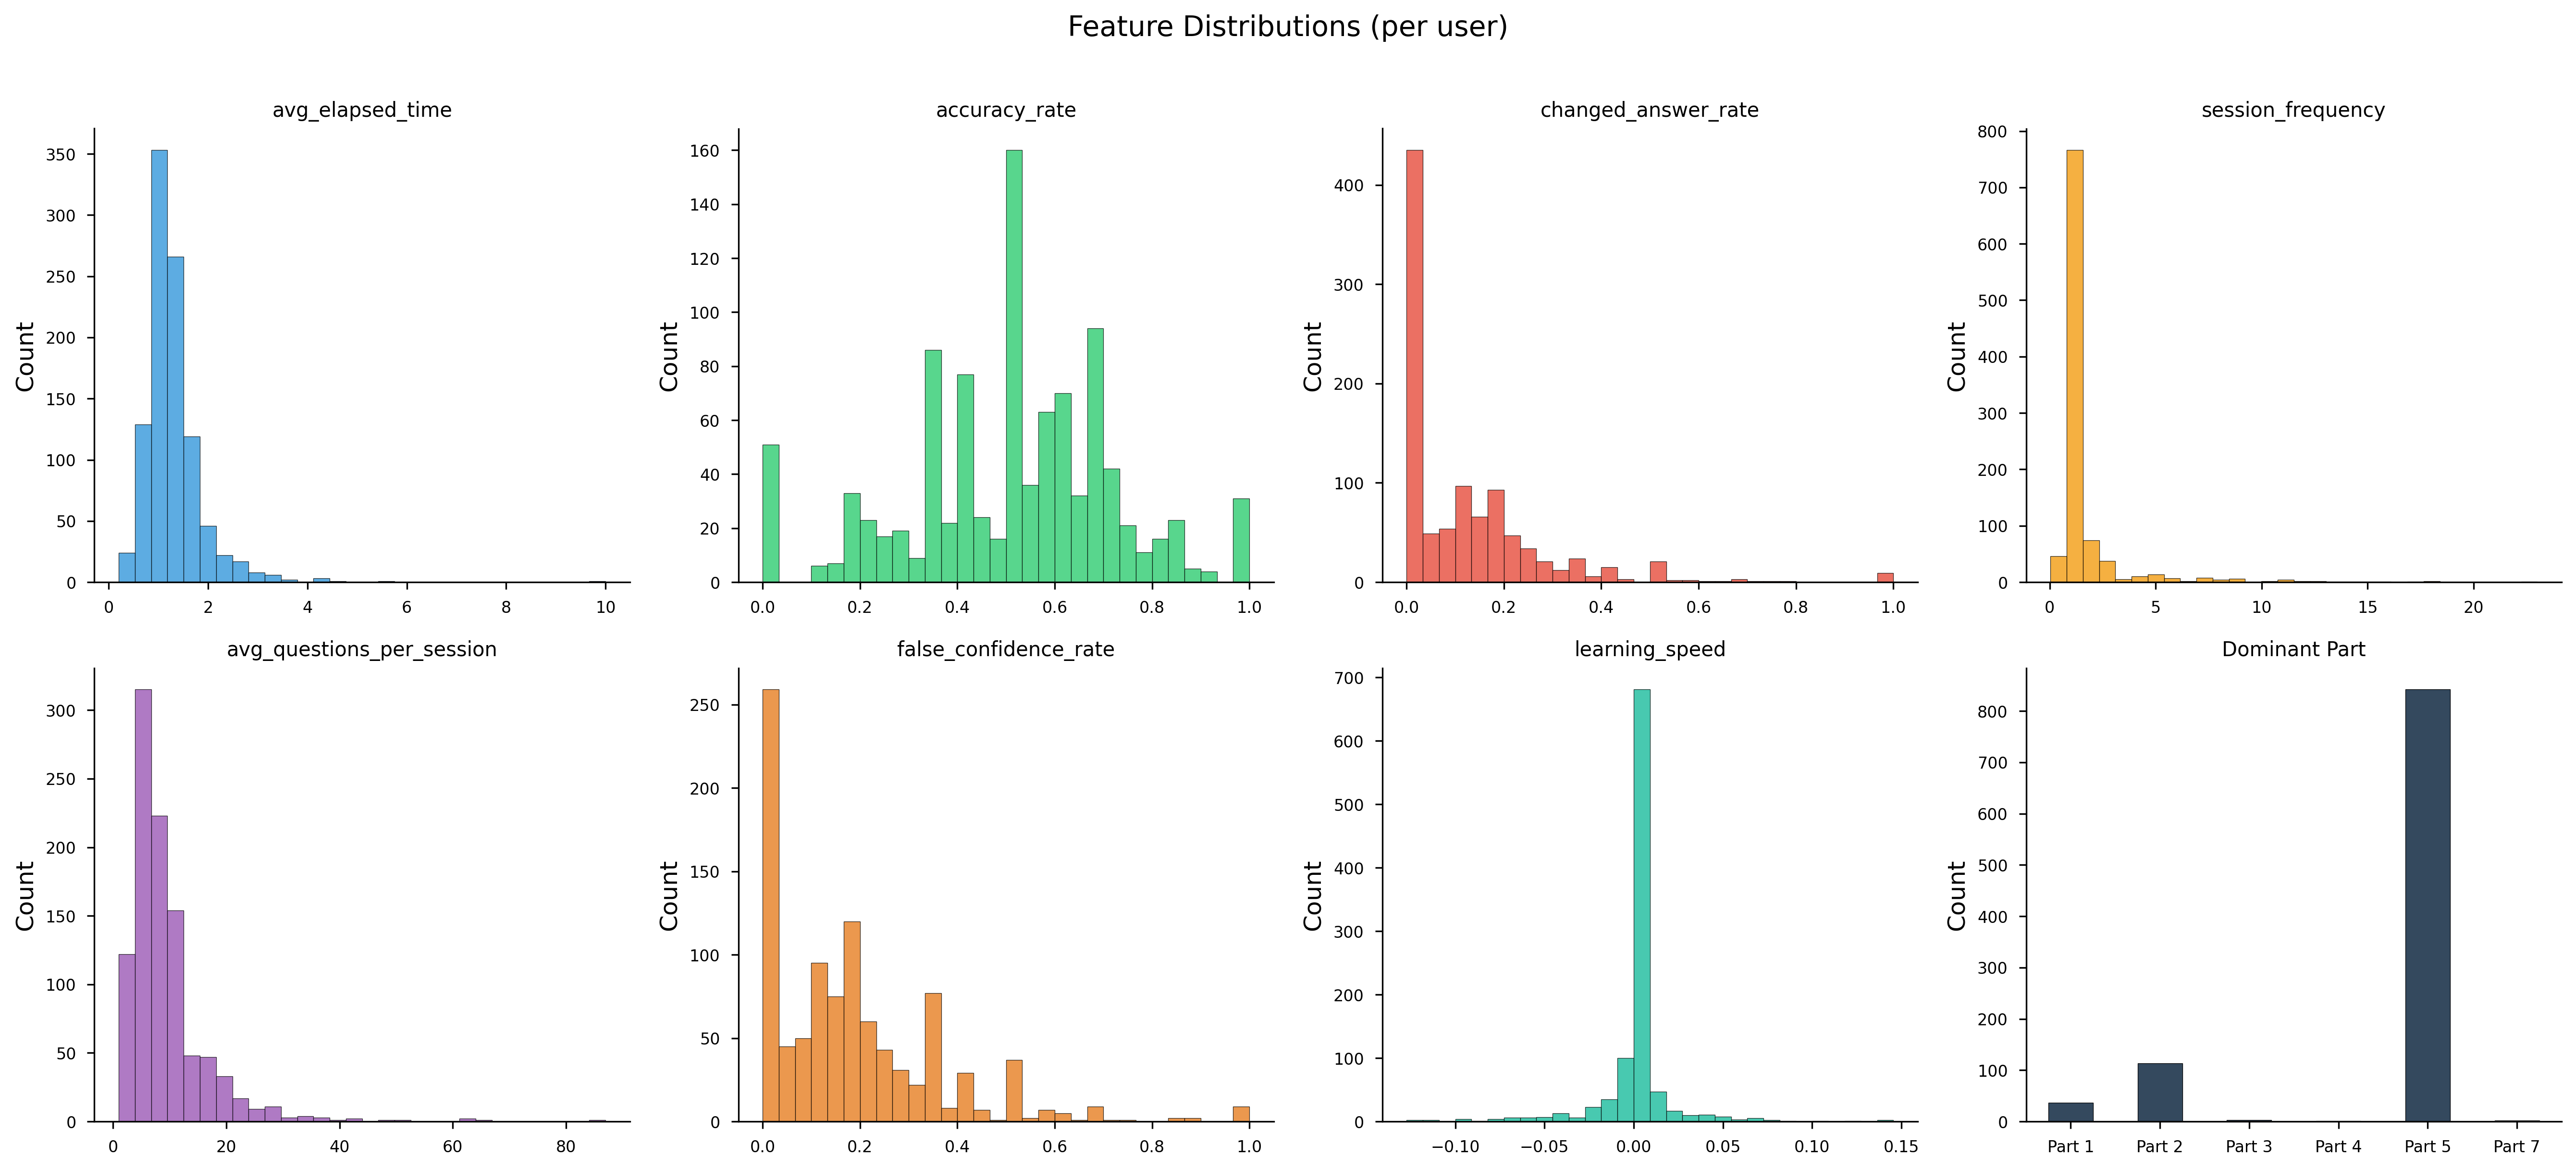

In [3]:
# Feature distributions
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
colors = ["#3498db", "#2ecc71", "#e74c3c", "#f39c12",
          "#9b59b6", "#e67e22", "#1abc9c"]

for i, feat in enumerate(FEATURE_NAMES_SCALAR):
    ax = axes[i // 4, i % 4]
    ax.hist(user_features[feat].dropna(), bins=30,
            color=colors[i % len(colors)], edgecolor="black",
            linewidth=0.3, alpha=0.8)
    ax.set_title(feat, fontsize=10)
    ax.set_ylabel("Count")
    sns.despine(ax=ax)

# Last subplot: dominant part distribution
ax = axes[1, 3]
dom_part = user_features[FEATURE_NAMES_ONEHOT].idxmax(axis=1).str.replace("dominant_part_", "Part ")
dom_part.value_counts().sort_index().plot.bar(
    ax=ax, color="#34495e", edgecolor="black", linewidth=0.3)
ax.set_title("Dominant Part", fontsize=10)
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=0)
sns.despine(ax=ax)

fig.suptitle("Feature Distributions (per user)", fontsize=14, y=1.01)
fig.tight_layout()
fig.savefig(RESULTS_DIR / "fig_cluster_feature_distributions.png")
plt.show()

## 2. Train Clusters (Silhouette Selection)

In [4]:
agent = PersonalizationAgent()
optimal_k = agent.train_clusters(user_features)

print(f"\nOptimal K: {optimal_k}")
print(f"Silhouette scores: {agent.silhouette_scores}")
print(f"Inertias: {agent.inertias}")
print(f"Cluster names: {agent._cluster_names}")

  File "C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.12_3.12.2800.0_x64__qbz5n2kfra8p0\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.12_3.12.2800.0_x64__qbz5n2kfra8p0\Lib\subprocess.py", line 1026, in __init_

mars.agent.personalization | K=3  silhouette=0.3972  inertia=9940.1


2026-04-02 18:05:43 | mars.agent.personalization     | INFO    | K=4  silhouette=0.4026  inertia=8928.8


mars.agent.personalization | K=4  silhouette=0.4026  inertia=8928.8


2026-04-02 18:05:43 | mars.agent.personalization     | INFO    | K=5  silhouette=0.4073  inertia=7884.0


...

2026-04-02 18:05:43 | mars.agent.personalization     | INFO    | Saved personalization model → models\personalization_kmeans.pkl


mars.agent.personalization | Saved personalization model → models\personalization_kmeans.pkl


2026-04-02 18:05:43 | mars.agent.personalization     | INFO    | Clusters: {3: 'Improving (n=2)', 2: 'Methodical (n=1)', 0: 'Struggling Guesser (n=842)', 1: 'Fast Learner (n=113)', 5: 'Cramming (n=37)', 4: 'Struggling (n=3)'}


mars.agent.personalization | Clusters: {3: 'Improving (n=2)', 2: 'Methodical (n=1)', 0: 'Struggling Guesser (n=842)', 1: 'Fast Learner (n=113)', 5: 'Cramming (n=37)', 4: 'Struggling (n=3)'}



Optimal K: 6
Silhouette scores: {3: 0.3972, 4: 0.4026, 5: 0.4073, 6: 0.4161, 7: 0.2046, 8: 0.2212}
Inertias: {3: 9940.13, 4: 8928.77, 5: 7883.97, 6: 6846.7, 7: 5987.8, 8: 5346.74}
Cluster names: {3: 'Improving', 2: 'Methodical', 0: 'Struggling Guesser', 1: 'Fast Learner', 5: 'Cramming', 4: 'Struggling'}


## 3. Elbow Plot + Silhouette Score Plot

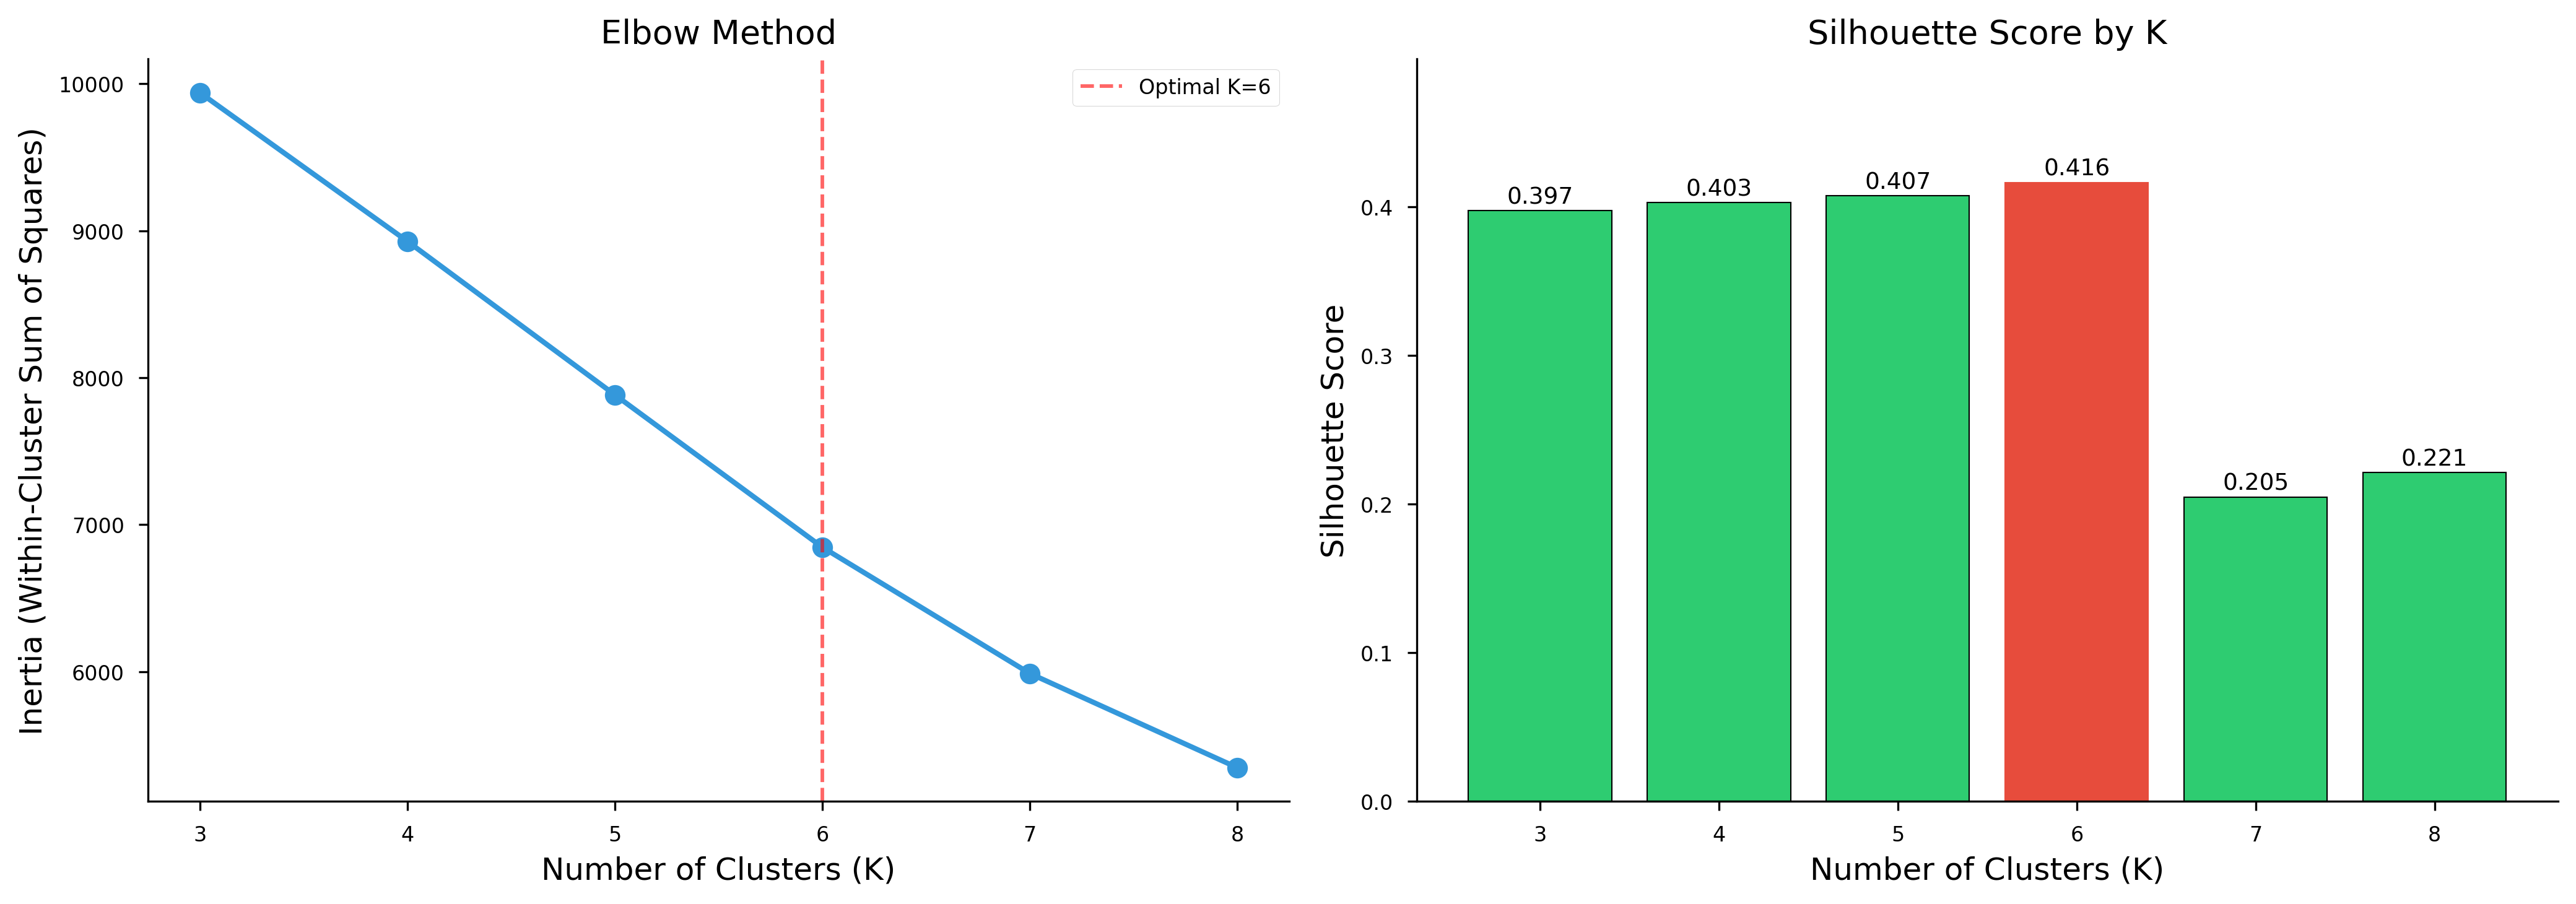

In [5]:
ks = sorted(agent.silhouette_scores.keys())
sils = [agent.silhouette_scores[k] for k in ks]
inertias = [agent.inertias[k] for k in ks]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Elbow plot
ax = axes[0]
ax.plot(ks, inertias, "o-", color="#3498db", markersize=8, linewidth=2)
ax.axvline(optimal_k, color="red", linestyle="--", alpha=0.6,
           label=f"Optimal K={optimal_k}")
ax.set_xlabel("Number of Clusters (K)")
ax.set_ylabel("Inertia (Within-Cluster Sum of Squares)")
ax.set_title("Elbow Method")
ax.set_xticks(ks)
ax.legend()
sns.despine(ax=ax)

# Right: Silhouette
ax = axes[1]
bars = ax.bar(ks, sils, color="#2ecc71", edgecolor="black", linewidth=0.5)
# Highlight optimal
bars[ks.index(optimal_k)].set_color("#e74c3c")
for bar, val in zip(bars, sils):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.005,
            f"{val:.3f}", ha="center", fontsize=9)
ax.set_xlabel("Number of Clusters (K)")
ax.set_ylabel("Silhouette Score")
ax.set_title("Silhouette Score by K")
ax.set_xticks(ks)
ax.set_ylim(0, max(sils) * 1.2)
sns.despine(ax=ax)

fig.tight_layout()
fig.savefig(RESULTS_DIR / "fig_cluster_elbow_silhouette.png")
plt.show()

## 4. t-SNE Visualization

UMAP not available, using t-SNE only


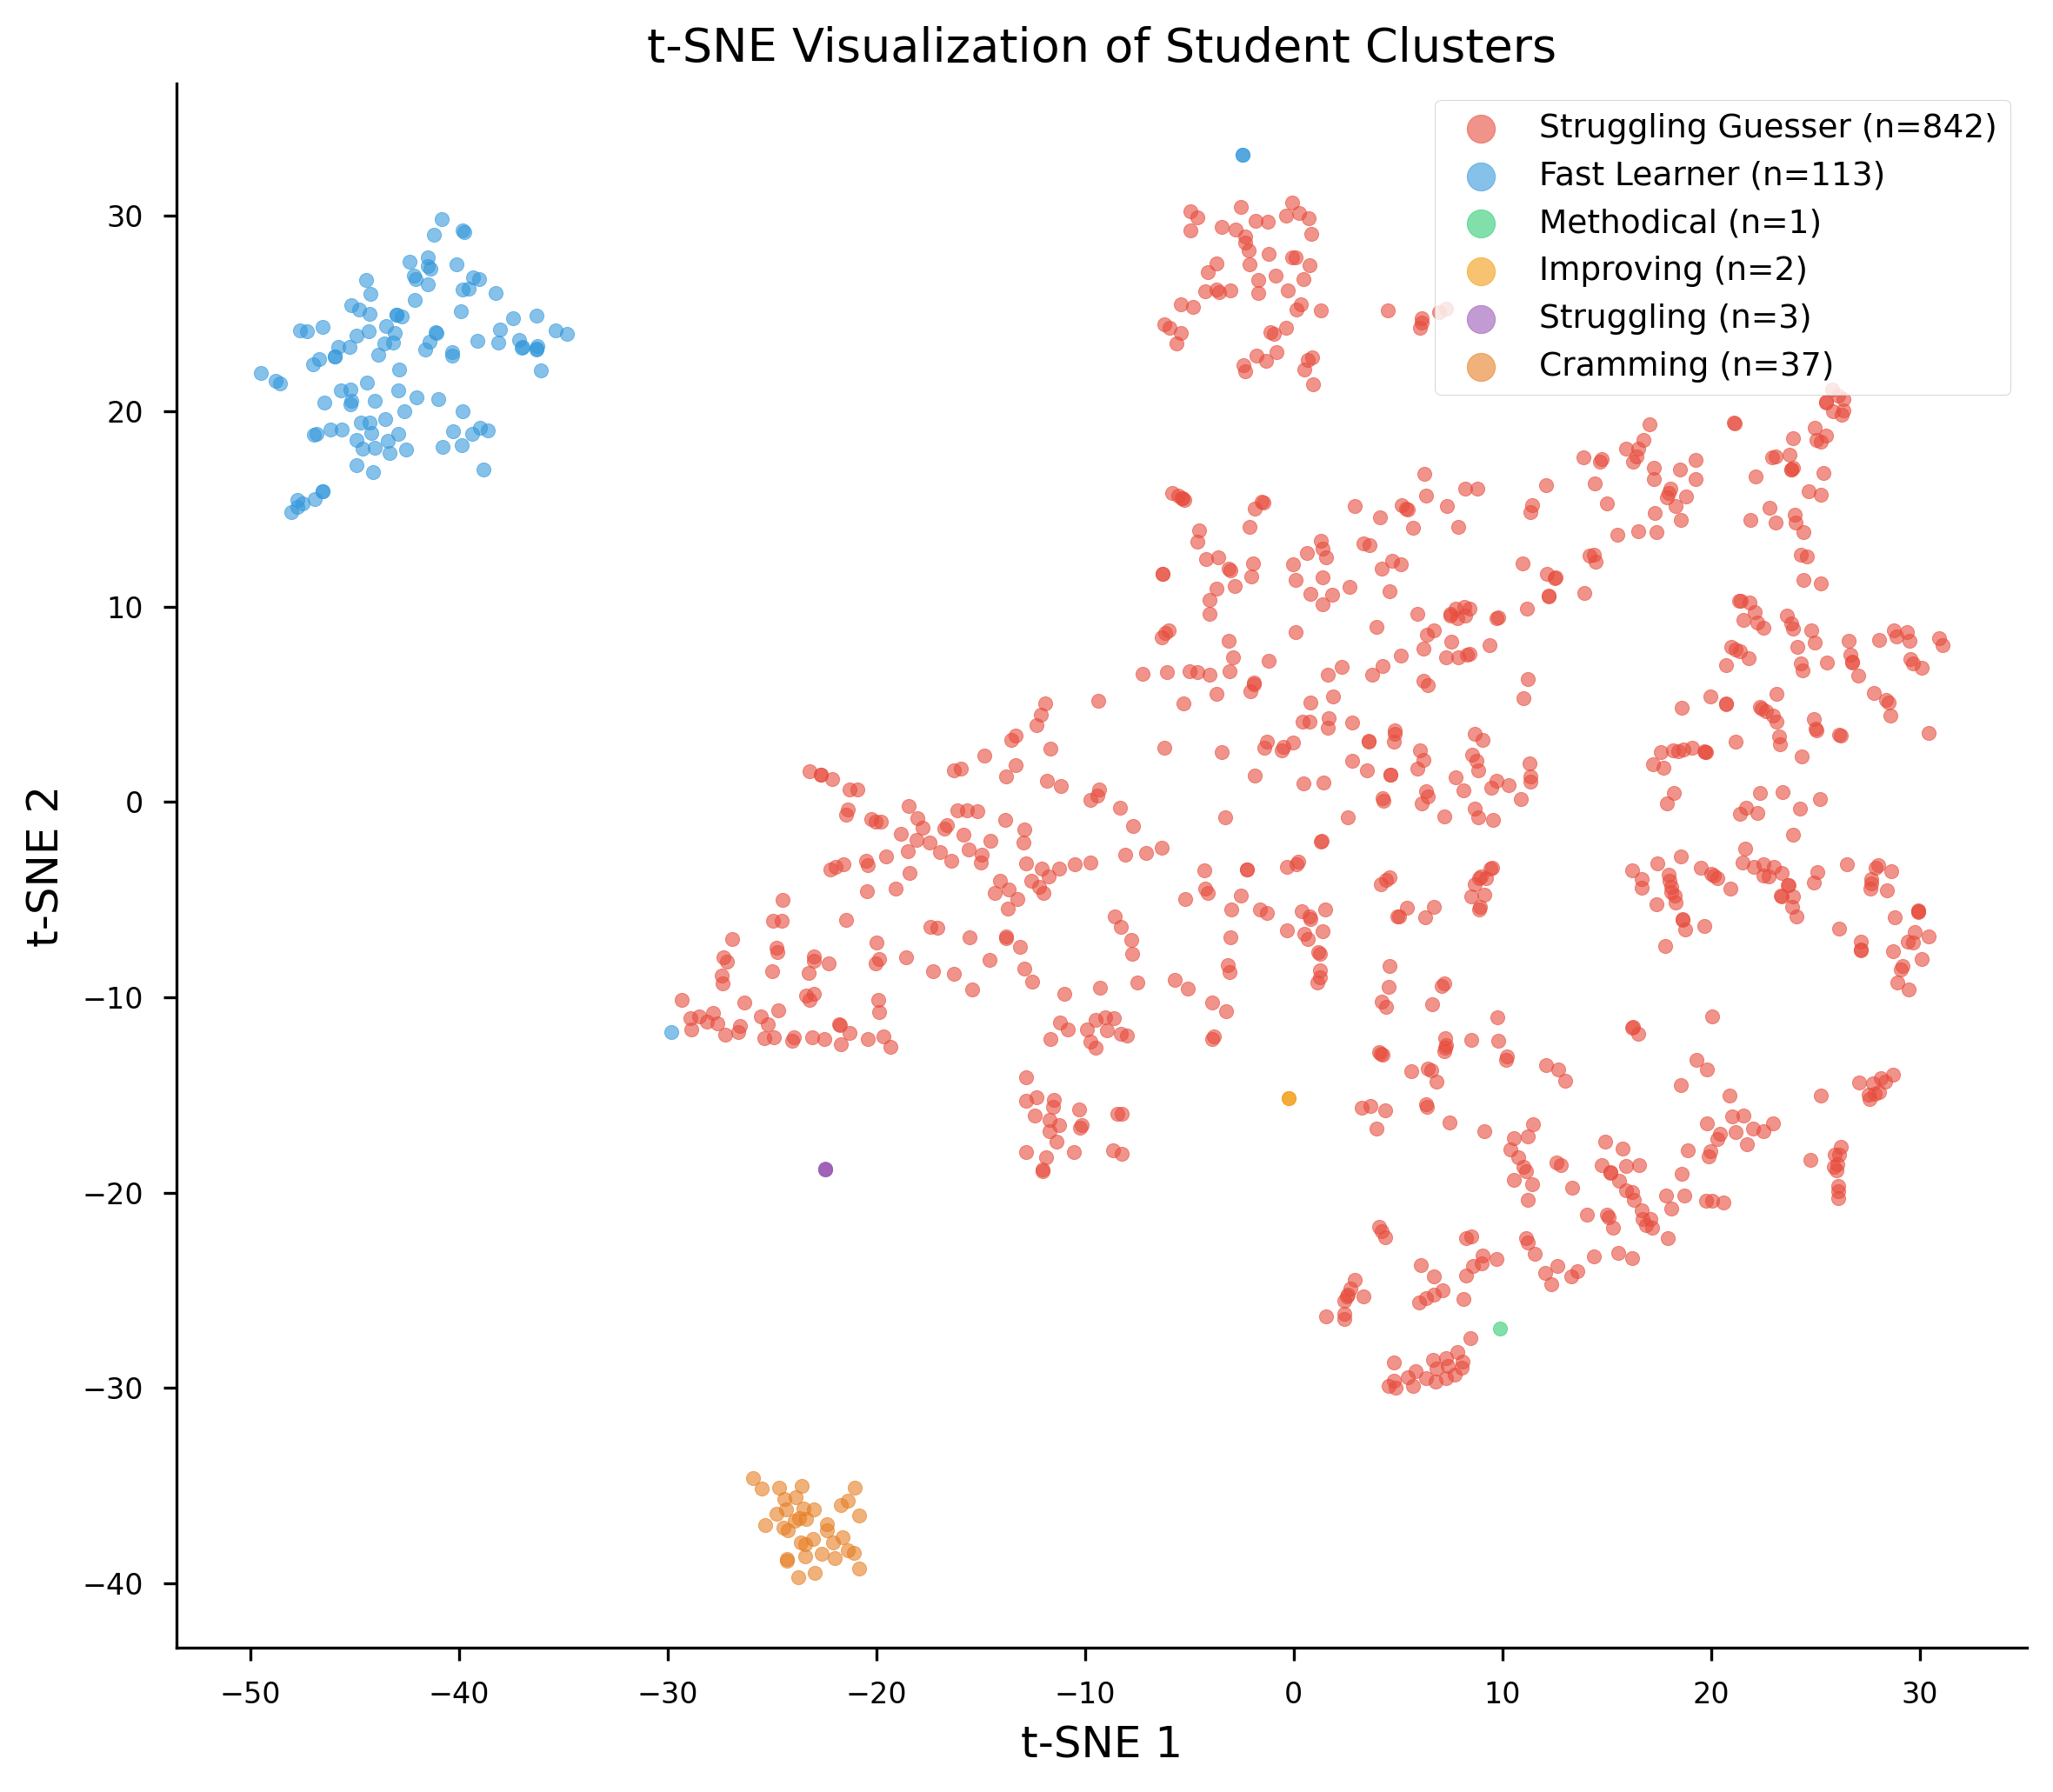

In [6]:
# Scale features for t-SNE
X_scaled = agent.scaler.transform(
    np.nan_to_num(user_features[FEATURE_NAMES].values, nan=0.0)
)

# Get cluster labels for all users
labels = agent.model.predict(X_scaled)

# t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
X_2d = tsne.fit_transform(X_scaled)

# Try UMAP if available
try:
    import umap
    reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15)
    X_umap = reducer.fit_transform(X_scaled)
    has_umap = True
except ImportError:
    has_umap = False
    print("UMAP not available, using t-SNE only")

n_plots = 2 if has_umap else 1
fig, axes = plt.subplots(1, n_plots, figsize=(8 * n_plots, 7))
if n_plots == 1:
    axes = [axes]

cluster_colors = ["#e74c3c", "#3498db", "#2ecc71", "#f39c12",
                  "#9b59b6", "#e67e22", "#1abc9c", "#34495e"]

# t-SNE plot
ax = axes[0]
for cid in range(optimal_k):
    mask = labels == cid
    name = agent._cluster_names.get(cid, f"Cluster {cid}")
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
              c=cluster_colors[cid % len(cluster_colors)],
              s=15, alpha=0.6, label=f"{name} (n={mask.sum()})")
ax.set_title("t-SNE Visualization of Student Clusters")
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.legend(fontsize=9, markerscale=2)
sns.despine(ax=ax)

# UMAP plot
if has_umap:
    ax = axes[1]
    for cid in range(optimal_k):
        mask = labels == cid
        name = agent._cluster_names.get(cid, f"Cluster {cid}")
        ax.scatter(X_umap[mask, 0], X_umap[mask, 1],
                  c=cluster_colors[cid % len(cluster_colors)],
                  s=15, alpha=0.6, label=f"{name} (n={mask.sum()})")
    ax.set_title("UMAP Visualization of Student Clusters")
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")
    ax.legend(fontsize=9, markerscale=2)
    sns.despine(ax=ax)

fig.tight_layout()
fig.savefig(RESULTS_DIR / "fig_cluster_tsne.png")
plt.show()

## 5. Radar Chart: Mean Profile per Cluster

In [7]:
# Get centroids in original scale
centroids_df = agent.get_centroids_df()
print("Cluster centroids (original scale):")
centroids_df.round(3)

Cluster centroids (original scale):


,cluster_name,avg_elapsed_time,accuracy_rate,changed_answer_rate,session_frequency,avg_questions_per_session,false_confidence_rate,learning_speed,dominant_part_1,dominant_part_2,dominant_part_3,dominant_part_4,dominant_part_5,dominant_part_6,dominant_part_7
0,Struggling Guesser,1.276,0.500,0.114,1.574,9.129,0.184,-0.001,-0.0,0.0,0.0,0.0,1.0,0.0,-0.0
1,Fast Learner,1.211,0.489,0.113,1.646,8.641,0.165,0.002,0.0,1.0,0.0,-0.0,0.0,0.0,-0.0
2,Methodical,1.999,1.000,0.000,1.000,1.000,0.000,0.000,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,Improving,3.859,0.455,0.562,3.258,4.667,0.098,0.006,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,Struggling,2.713,0.543,0.440,5.902,9.527,0.083,0.001,0.0,0.0,1.0,0.0,0.0,0.0,0.0
5,Cramming,1.353,0.570,0.145,2.171,14.127,0.149,0.003,1.0,-0.0,0.0,0.0,-0.0,0.0,-0.0


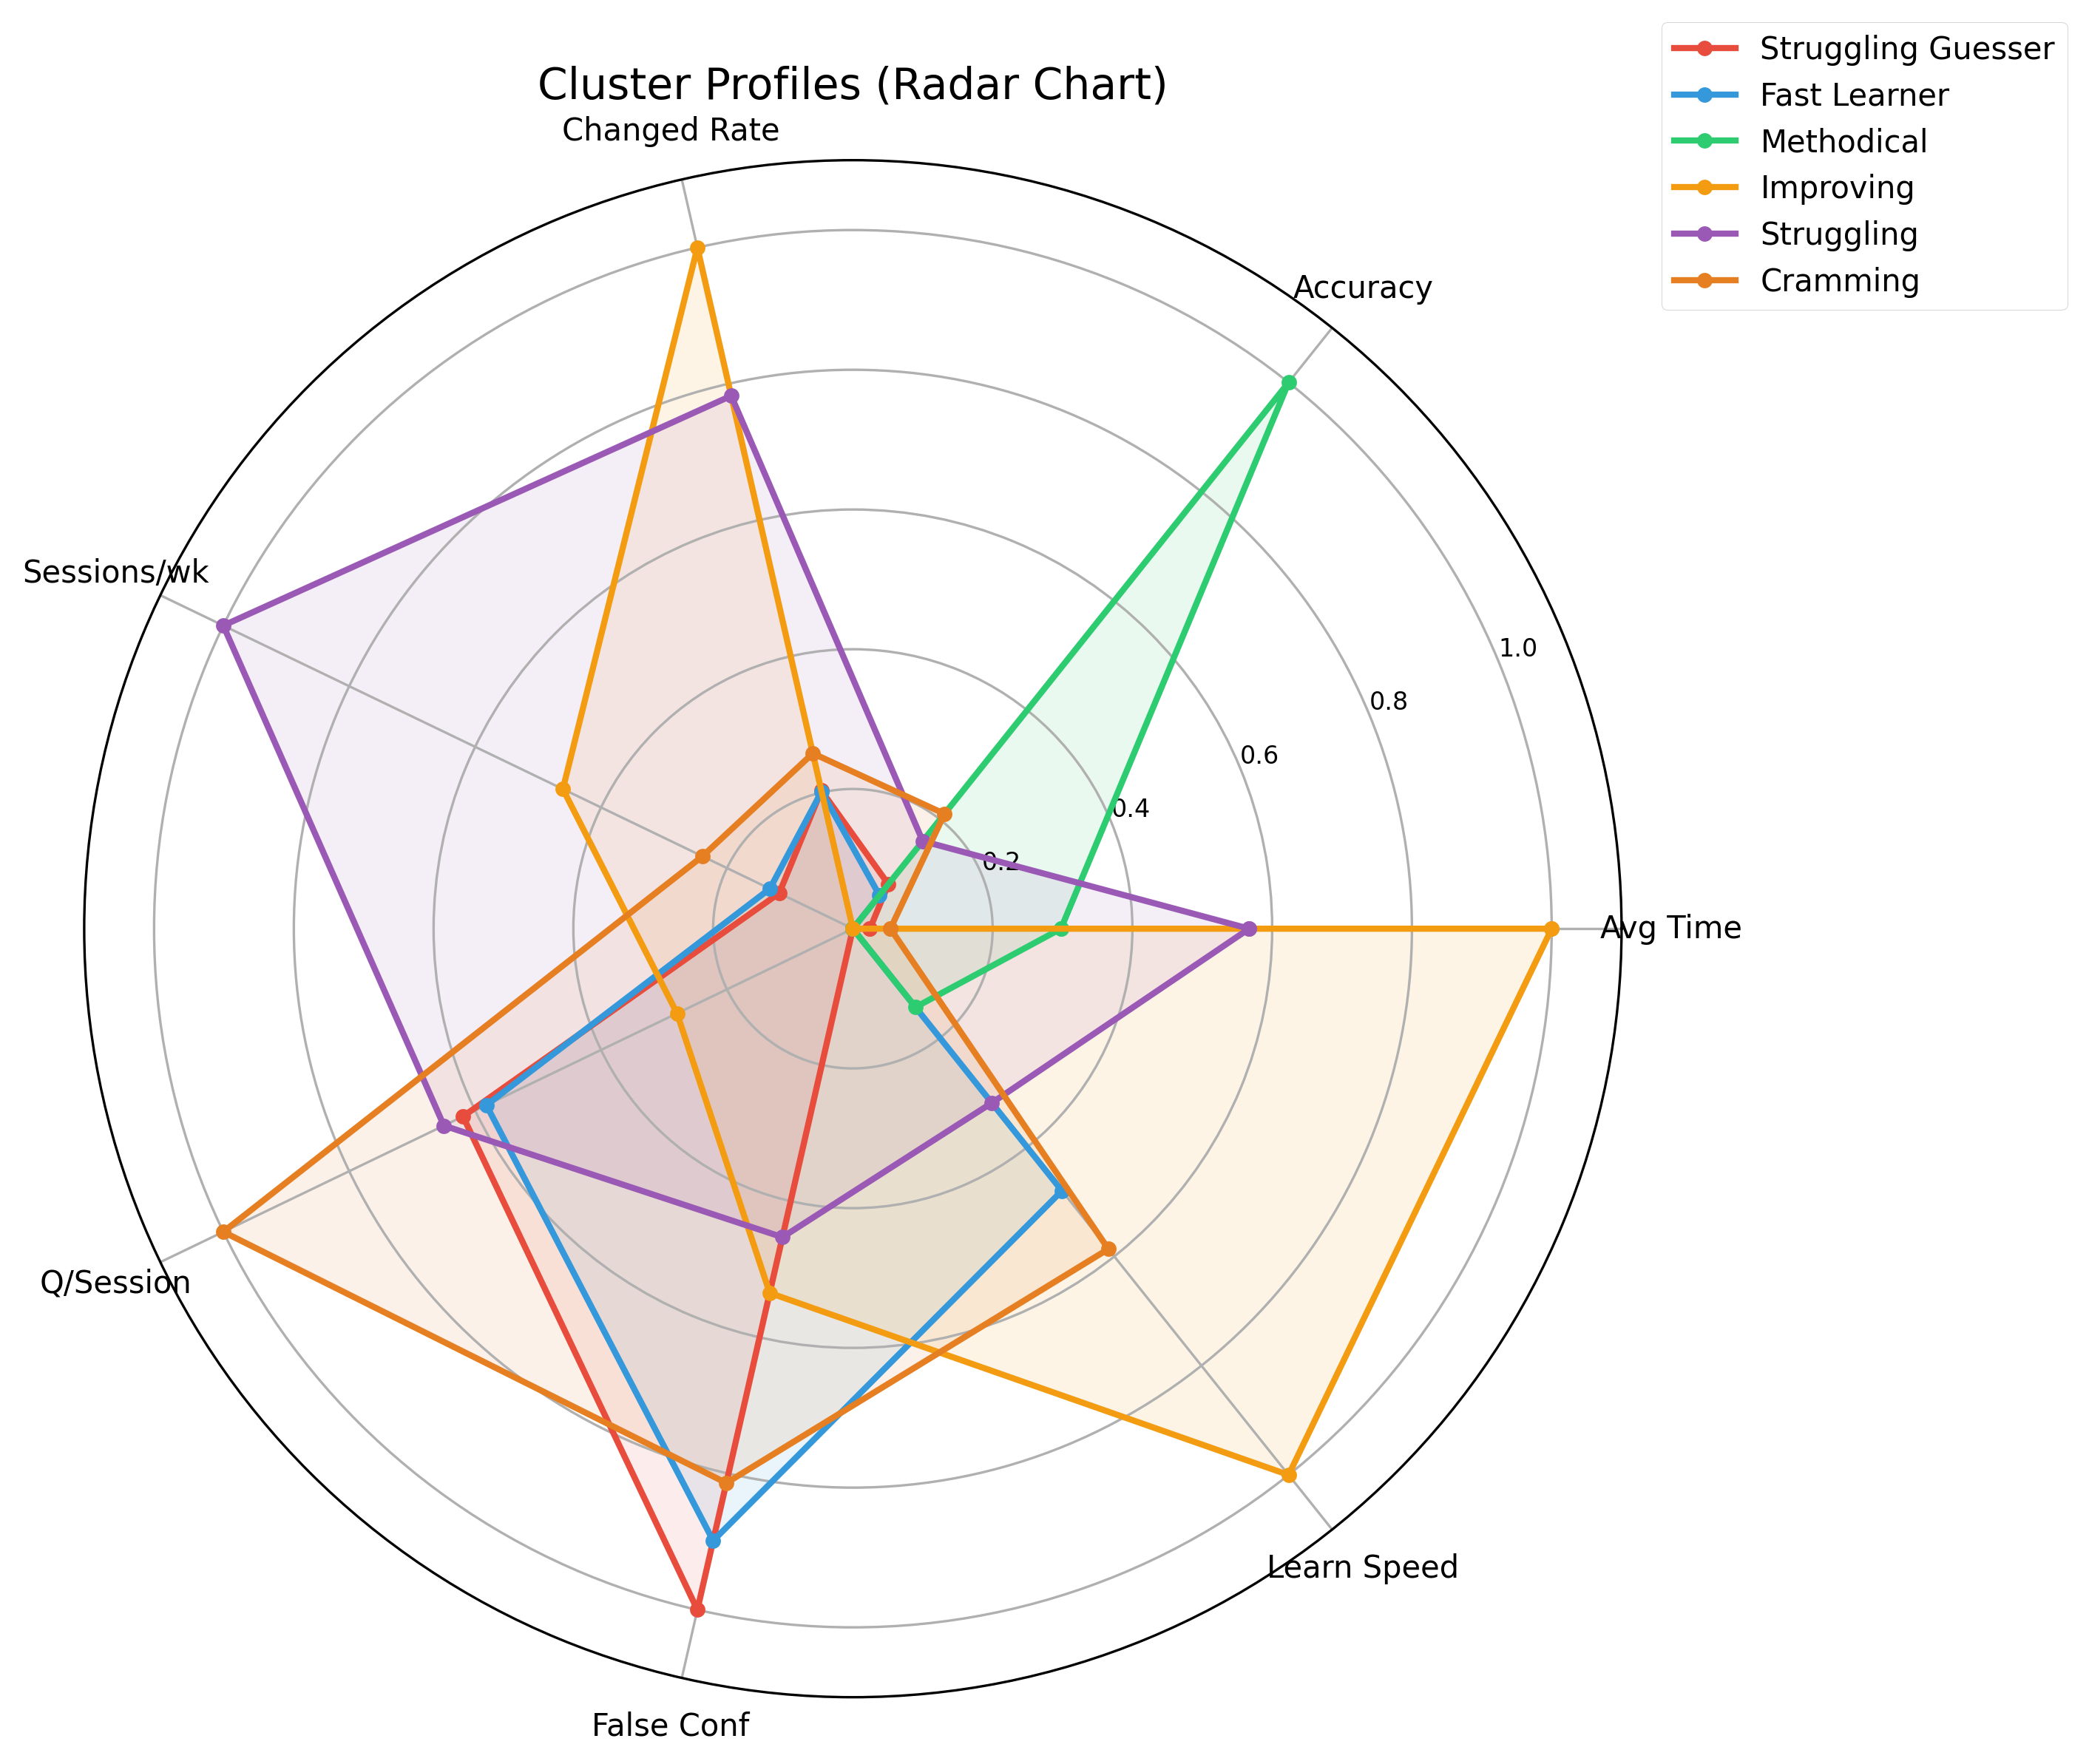

In [8]:
# Radar chart with scalar features (7 axes)
from matplotlib.patches import FancyBboxPatch

radar_features = FEATURE_NAMES_SCALAR
n_features = len(radar_features)
angles = np.linspace(0, 2 * np.pi, n_features, endpoint=False).tolist()
angles += angles[:1]  # close the polygon

# Normalise centroids to [0, 1] for radar
centroid_values = centroids_df[radar_features].values
mins = centroid_values.min(axis=0)
maxs = centroid_values.max(axis=0)
ranges = maxs - mins
ranges[ranges == 0] = 1.0
normed = (centroid_values - mins) / ranges

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))

for cid in range(optimal_k):
    values = normed[cid].tolist()
    values += values[:1]  # close
    name = agent._cluster_names.get(cid, f"Cluster {cid}")
    color = cluster_colors[cid % len(cluster_colors)]
    ax.plot(angles, values, "o-", color=color, linewidth=2,
            markersize=5, label=name)
    ax.fill(angles, values, color=color, alpha=0.1)

# Labels
ax.set_xticks(angles[:-1])
short_names = [
    "Avg Time", "Accuracy", "Changed Rate",
    "Sessions/wk", "Q/Session", "False Conf", "Learn Speed",
]
ax.set_xticklabels(short_names, fontsize=10)
ax.set_ylim(0, 1.1)
ax.set_title("Cluster Profiles (Radar Chart)", fontsize=14, pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1), fontsize=10)

fig.savefig(RESULTS_DIR / "fig_cluster_radar.png")
plt.show()

## 6. Cluster Characteristics Table


Cluster Summary:
 cluster_id       cluster_name  size  pct  mean_avg_elapsed_time  mean_accuracy_rate  mean_changed_answer_rate  mean_session_frequency  mean_avg_questions_per_session  mean_false_confidence_rate  mean_learning_speed
          0 Struggling Guesser   842 84.4                 1.2755              0.4997                    0.1141                  1.5736                          9.1290                      0.1837              -0.0010
          1       Fast Learner   113 11.3                 1.2109              0.4886                    0.1133                  1.6465                          8.6411                      0.1650               0.0023
          2         Methodical     1  0.1                 1.9994              1.0000                    0.0000                  1.0000                          1.0000                      0.0000               0.0000
          3          Improving     2  0.2                 3.8591              0.4554                    0.5625        

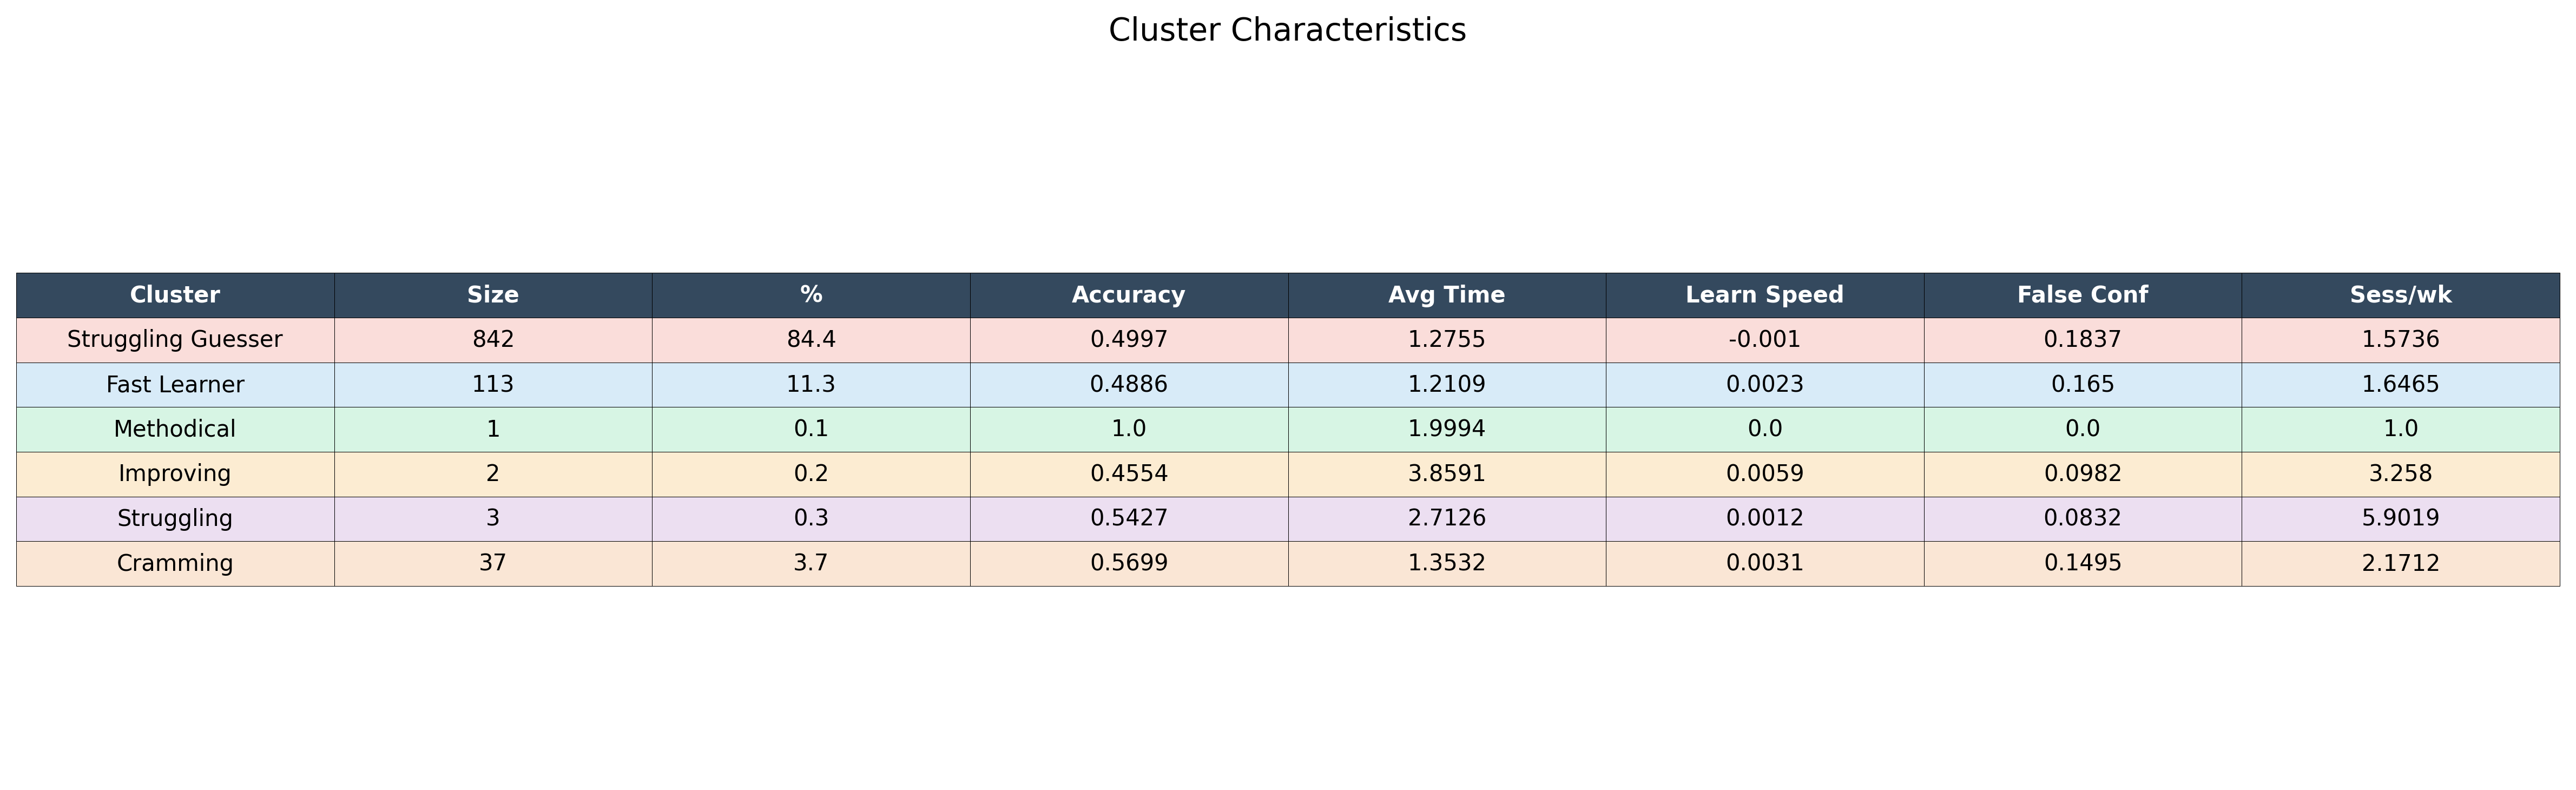

In [9]:
summary = agent.cluster_summary()
print("\nCluster Summary:")
print(summary.to_string(index=False))

# Save for paper
summary.to_csv(RESULTS_DIR / "cluster_summary.csv", index=False)

# Styled table as figure
fig, ax = plt.subplots(figsize=(16, 2 + 0.5 * len(summary)))
ax.axis("off")

# Prepare display columns
disp = summary[[
    "cluster_name", "size", "pct",
    "mean_accuracy_rate", "mean_avg_elapsed_time",
    "mean_learning_speed", "mean_false_confidence_rate",
    "mean_session_frequency",
]].copy()
disp.columns = [
    "Cluster", "Size", "%",
    "Accuracy", "Avg Time",
    "Learn Speed", "False Conf",
    "Sess/wk",
]

table = ax.table(
    cellText=disp.values,
    colLabels=disp.columns,
    cellLoc="center",
    loc="center",
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.5)

# Color header
for j in range(len(disp.columns)):
    table[0, j].set_facecolor("#34495e")
    table[0, j].set_text_props(color="white", fontweight="bold")

# Color cluster rows
for i in range(len(disp)):
    for j in range(len(disp.columns)):
        table[i + 1, j].set_facecolor(
            cluster_colors[i % len(cluster_colors)] + "30"  # with alpha
        )

ax.set_title("Cluster Characteristics", fontsize=14, pad=20)
fig.tight_layout()
fig.savefig(RESULTS_DIR / "fig_cluster_table.png")
plt.show()

## 7. Accuracy Distribution by Cluster (Box Plot)

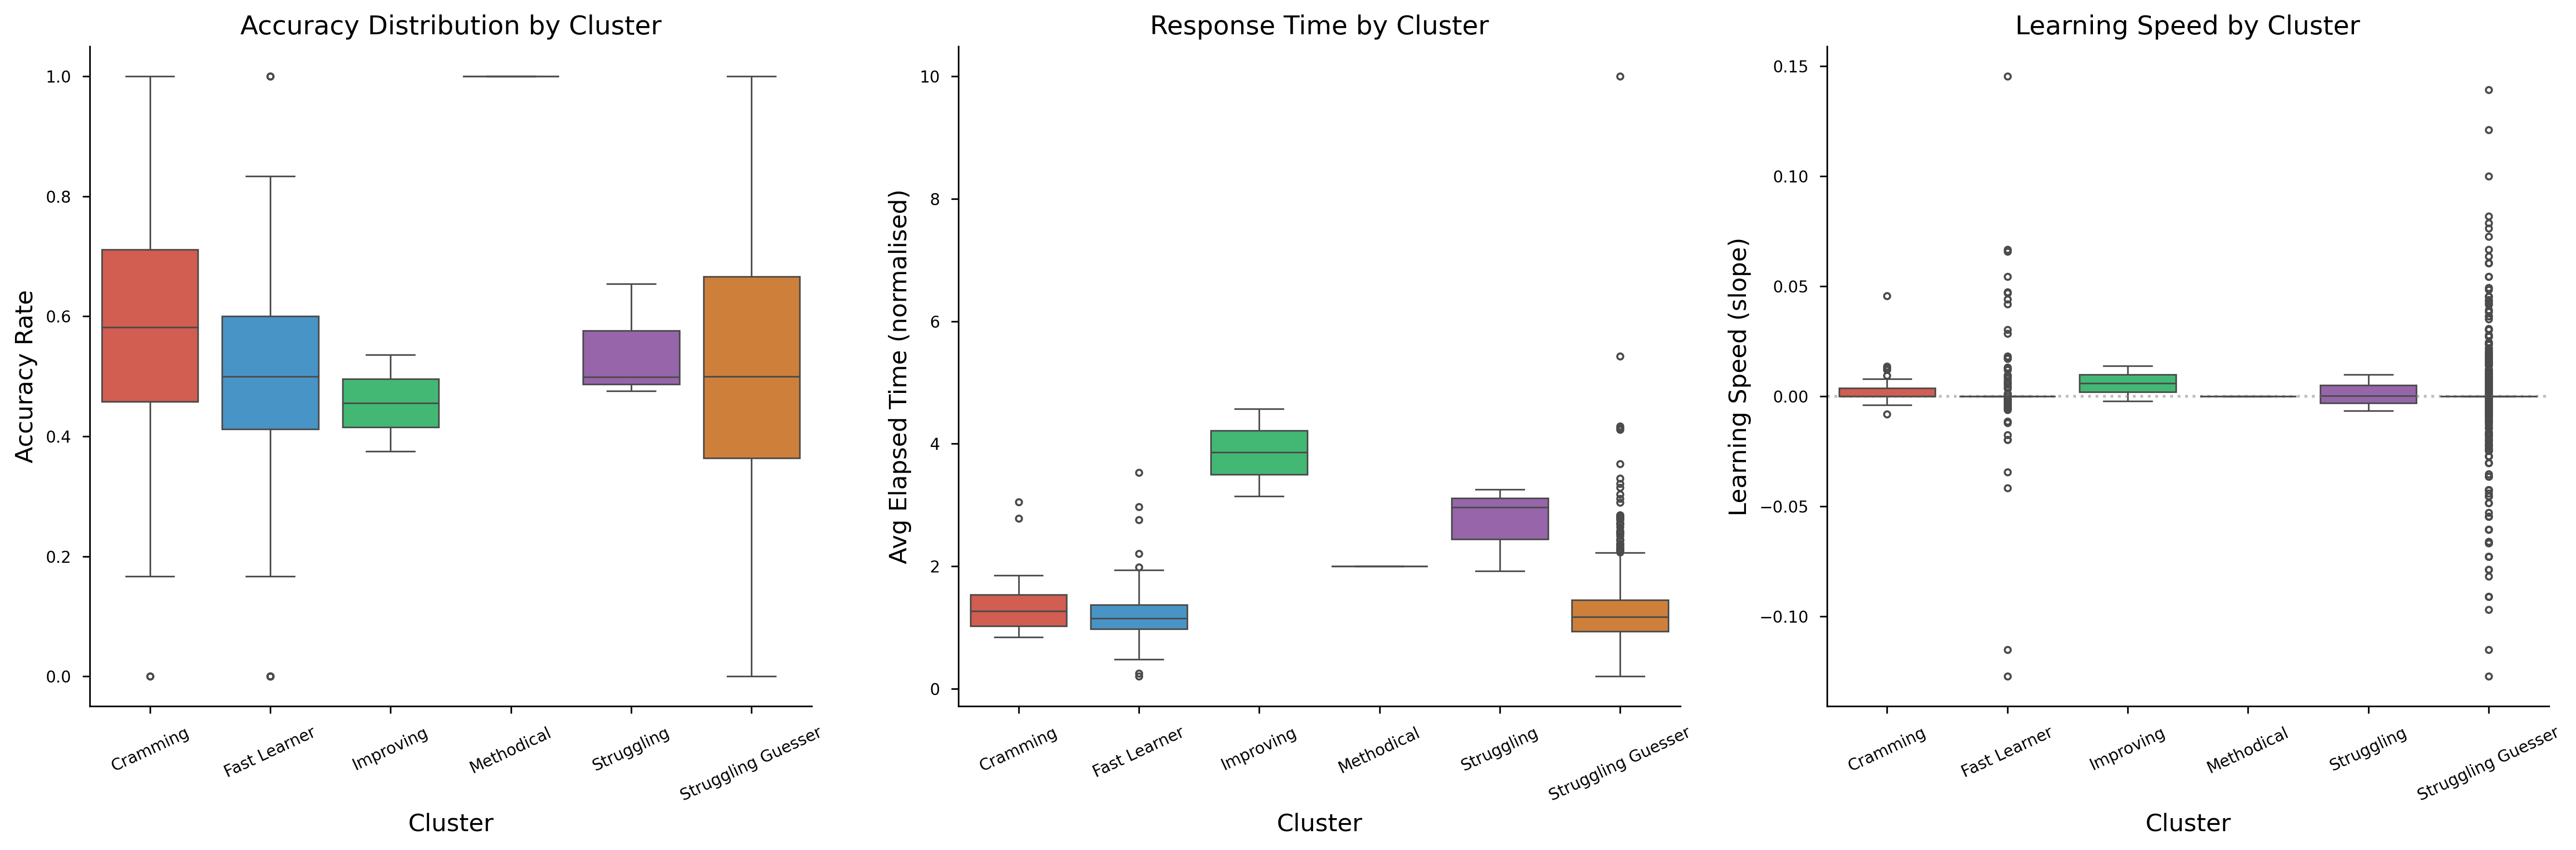

In [10]:
# Build DataFrame with cluster labels
plot_df = user_features[FEATURE_NAMES_SCALAR].copy()
plot_df["cluster"] = labels
plot_df["cluster_name"] = [
    agent._cluster_names.get(c, f"Cluster {c}") for c in labels
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Box plot: accuracy by cluster
ax = axes[0]
order = sorted(plot_df["cluster_name"].unique())
palette = {name: cluster_colors[i % len(cluster_colors)]
           for i, name in enumerate(order)}
sns.boxplot(data=plot_df, x="cluster_name", y="accuracy_rate",
            order=order, palette=palette, ax=ax,
            linewidth=0.8, fliersize=3)
ax.set_xlabel("Cluster")
ax.set_ylabel("Accuracy Rate")
ax.set_title("Accuracy Distribution by Cluster")
ax.tick_params(axis="x", rotation=25)
sns.despine(ax=ax)

# Box plot: avg elapsed time by cluster
ax = axes[1]
sns.boxplot(data=plot_df, x="cluster_name", y="avg_elapsed_time",
            order=order, palette=palette, ax=ax,
            linewidth=0.8, fliersize=3)
ax.set_xlabel("Cluster")
ax.set_ylabel("Avg Elapsed Time (normalised)")
ax.set_title("Response Time by Cluster")
ax.tick_params(axis="x", rotation=25)
sns.despine(ax=ax)

# Box plot: learning speed by cluster
ax = axes[2]
sns.boxplot(data=plot_df, x="cluster_name", y="learning_speed",
            order=order, palette=palette, ax=ax,
            linewidth=0.8, fliersize=3)
ax.set_xlabel("Cluster")
ax.set_ylabel("Learning Speed (slope)")
ax.set_title("Learning Speed by Cluster")
ax.axhline(0, color="gray", linestyle=":", alpha=0.5)
ax.tick_params(axis="x", rotation=25)
sns.despine(ax=ax)

fig.tight_layout()
fig.savefig(RESULTS_DIR / "fig_cluster_boxplots.png")
plt.show()

## 8. Feature Correlation Heatmap (per cluster)

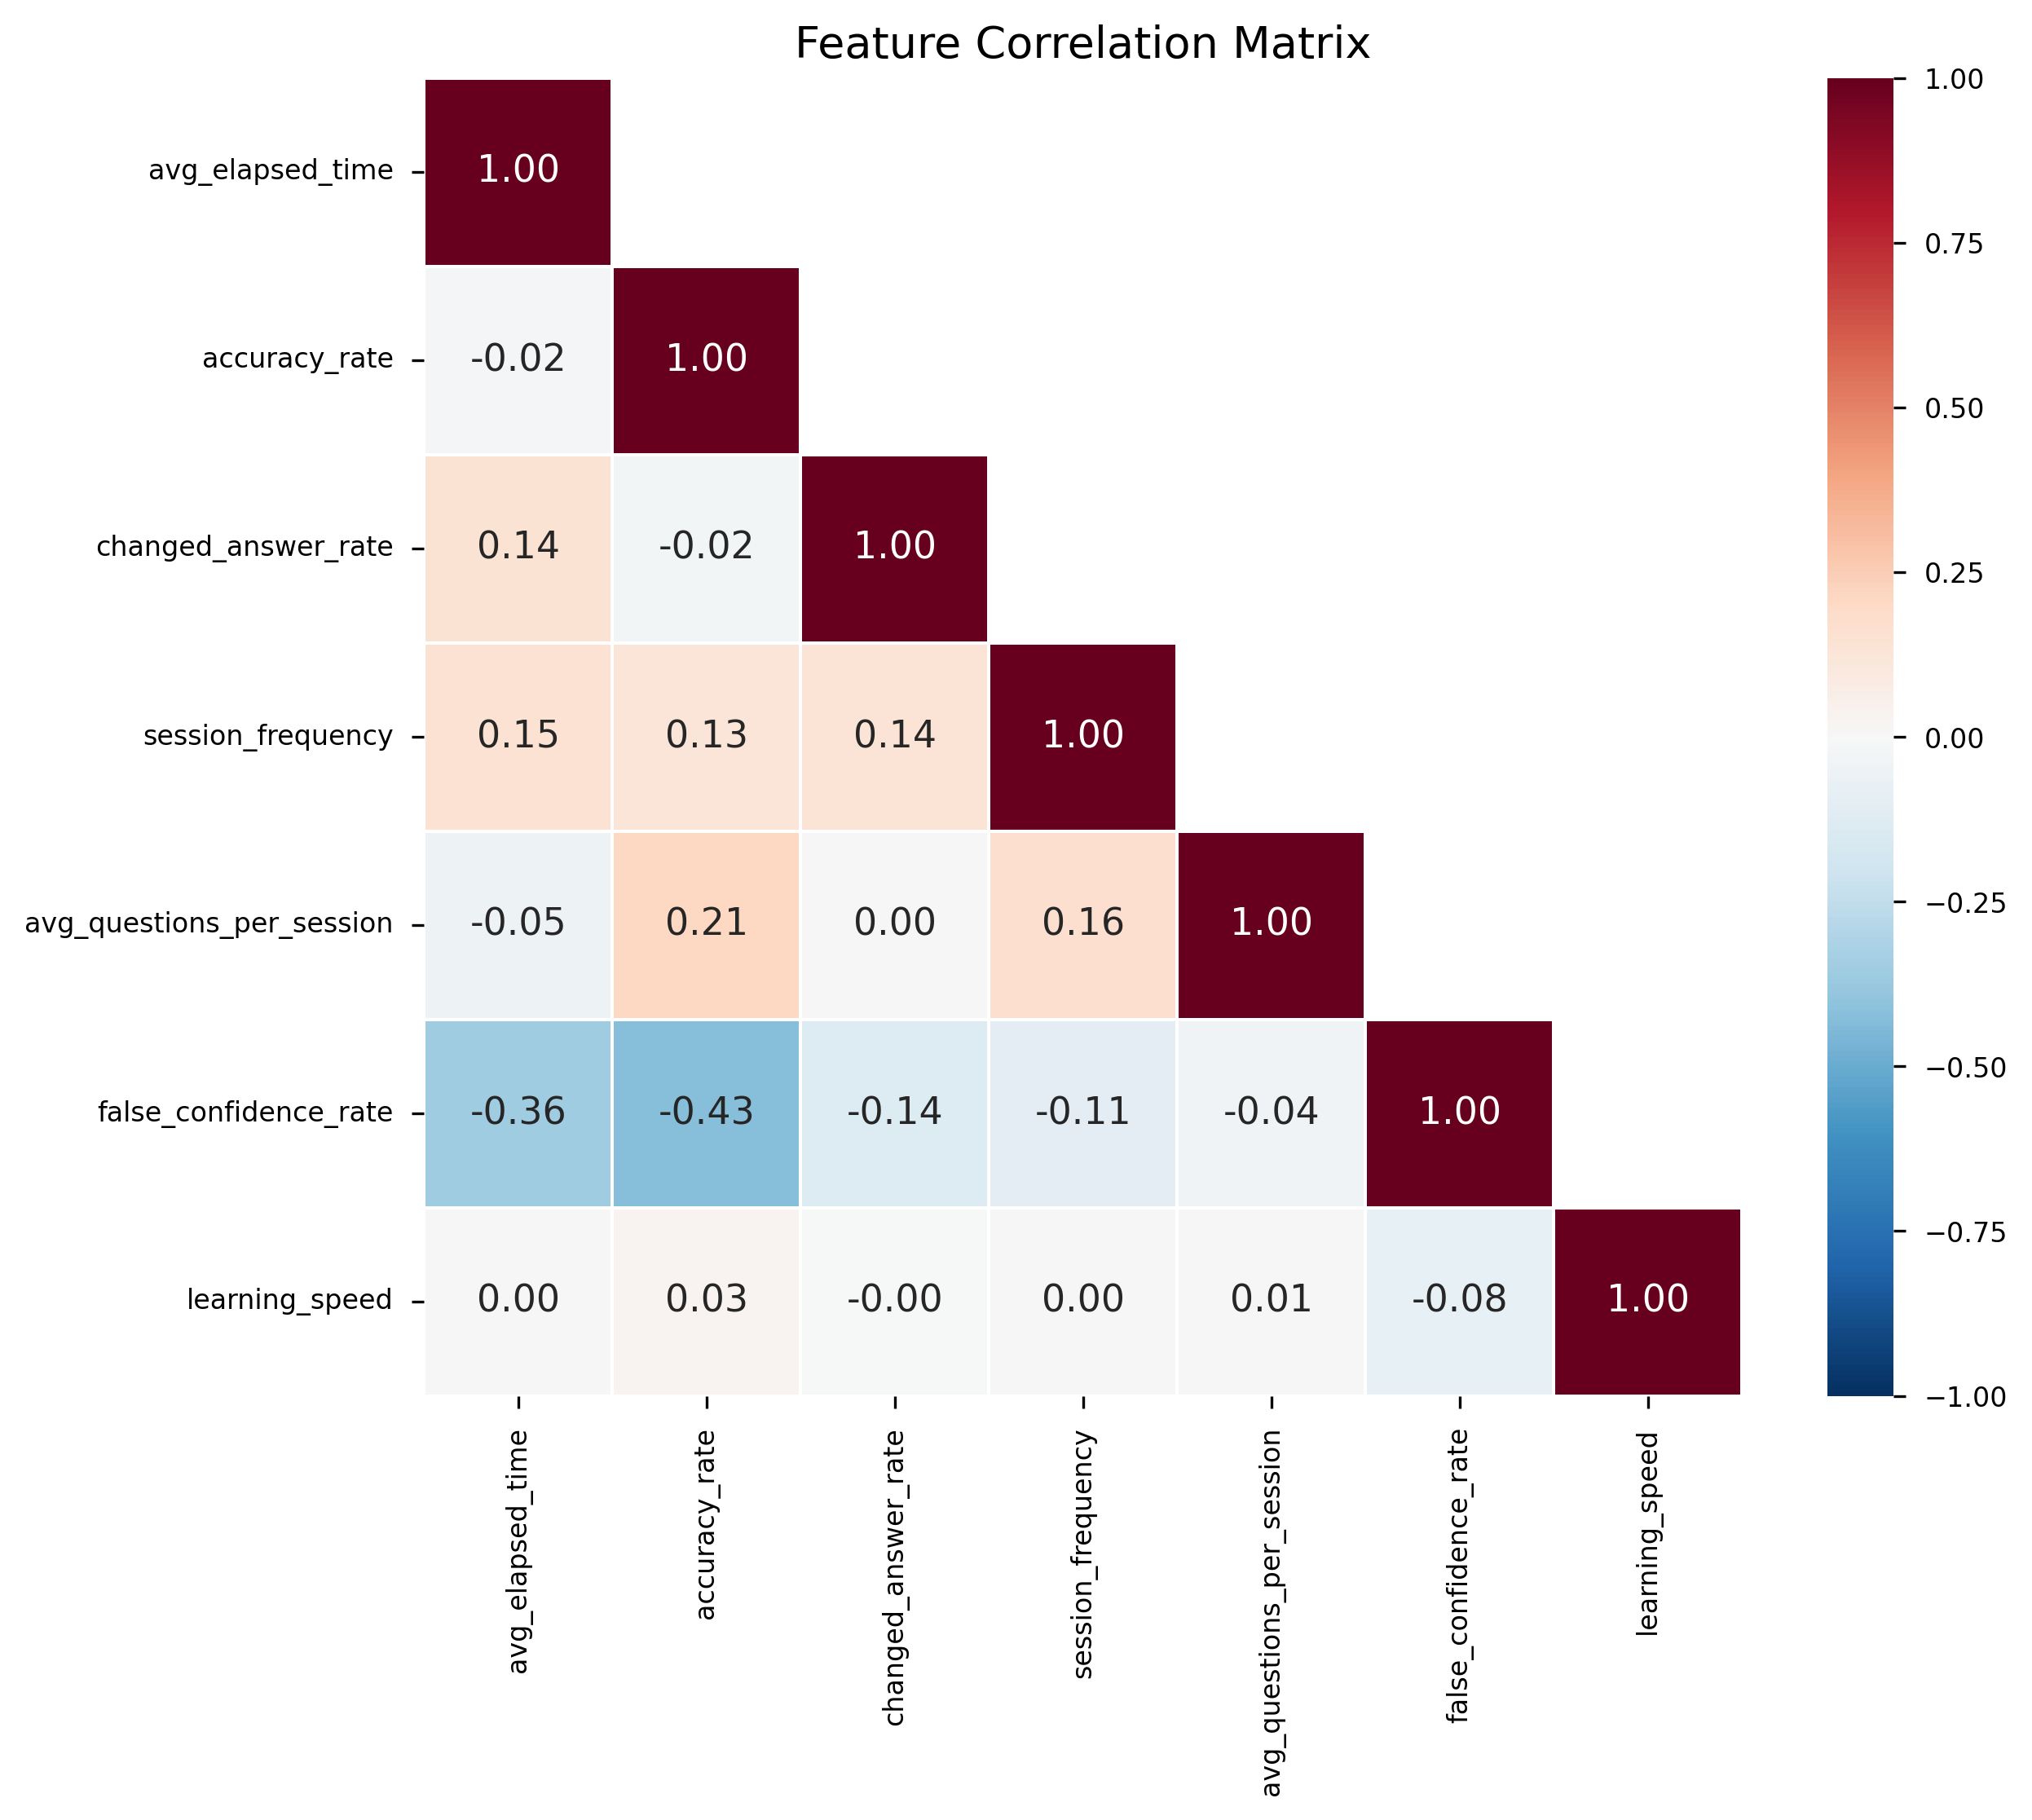

In [11]:
# Overall correlation
fig, ax = plt.subplots(figsize=(9, 7))
corr = user_features[FEATURE_NAMES_SCALAR].corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, square=True, linewidths=0.5, ax=ax,
            vmin=-1, vmax=1)
ax.set_title("Feature Correlation Matrix")

fig.savefig(RESULTS_DIR / "fig_cluster_feature_correlation.png")
plt.show()

## 9. Agent Integration Test

In [12]:
# Test assign_cluster
test_user = user_features.index[0]
profile = agent.assign_cluster(str(test_user))
print(f"User: {test_user}")
print(f"Cluster: {profile['cluster_name']}")
print(f"User type: {profile['user_type']}")
print(f"Distance to centroid: {profile['distance_to_centroid']}")

# Test get_user_type
user_type = agent.get_user_type(str(test_user))
print(f"\nget_user_type: {user_type}")

# Test personalize
pers_result = agent.personalize(str(test_user))
print(f"\npersonalize result:")
print(f"  Cluster: {pers_result['cluster_name']}")
print(f"  Adjustments: {pers_result['adjustments']}")

# Test cold start
cold_result = agent.assign_cluster(
    user_id="new_user_999",
    diagnostic={
        "responses": [
            {"correct": True, "part_id": 1},
            {"correct": True, "part_id": 2},
            {"correct": False, "part_id": 3},
        ],
    },
    confidence={
        "class_names": ["SOLID", "UNSURE_CORRECT", "FALSE_CONFIDENCE"],
    },
)
print(f"\nCold start user: {cold_result['cluster_name']}")

User: u10219
Cluster: Fast Learner
User type: Fast Learner
Distance to centroid: 3.0891

get_user_type: Fast Learner

personalize result:
  Cluster: Fast Learner
  Adjustments: {'difficulty_adjustment': 0.3, 'pacing': 'accelerated', 'content_mix': 'challenge_heavy', 'review_frequency': 'low'}

Cold start user: Cramming


## 10. Summary for Paper

In [13]:
print("\n" + "=" * 55)
print("  K-Means Clustering — Summary for Paper")
print("=" * 55)
print(f"  Optimal K:              {optimal_k}")
print(f"  Silhouette Score:       {agent.silhouette_scores[optimal_k]:.4f}")
print(f"  Features:               {len(FEATURE_NAMES)} ({len(FEATURE_NAMES_SCALAR)} scalar + 7 one-hot)")
print(f"  Users clustered:        {len(user_features)}")
print()
for cid in range(optimal_k):
    n = sum(1 for v in agent._user_clusters.values() if v == cid)
    name = agent._cluster_names.get(cid, f"Cluster {cid}")
    print(f"  Cluster {cid} ({name:20s}): n={n}")

print(f"\n  Figures saved to: {RESULTS_DIR.resolve()}")
print("=" * 55)


  K-Means Clustering — Summary for Paper
  Optimal K:              6
  Silhouette Score:       0.4161
  Features:               14 (7 scalar + 7 one-hot)
  Users clustered:        999

  Cluster 0 (Struggling Guesser  ): n=842
  Cluster 1 (Fast Learner        ): n=113
  Cluster 2 (Methodical          ): n=1
  Cluster 3 (Improving           ): n=2
  Cluster 4 (Struggling          ): n=3
  Cluster 5 (Cramming            ): n=38

  Figures saved to: C:\Users\user\Documents\Diser\система\ednet-mars\results


## Cluster Validation: CH, DB, Stability

In [14]:
# === Calinski-Harabasz, Davies-Bouldin, Cluster Stability ===
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score
from sklearn.metrics import adjusted_rand_score
from sklearn.cluster import KMeans

# Internal validation indices
ch = calinski_harabasz_score(X_scaled, labels)
db = davies_bouldin_score(X_scaled, labels)
print(f"Internal Validation Indices (K={optimal_k}):")
print(f"  Calinski-Harabasz Index: {ch:.1f}  (higher = better)")
print(f"  Davies-Bouldin Index:    {db:.3f}  (lower = better)")

# Silhouette score (already computed by agent, but print explicitly)
from sklearn.metrics import silhouette_score
sil = silhouette_score(X_scaled, labels)
print(f"  Silhouette Score:        {sil:.3f}  (closer to 1 = better)")

# Cluster Stability (ARI across 10 random restarts)
print(f"\nCluster Stability Analysis (10 random restarts, K={optimal_k}):")
labels_runs = []
for s in range(10):
    km = KMeans(n_clusters=optimal_k, random_state=s, n_init=10)
    labels_runs.append(km.fit_predict(X_scaled))

ari_pairs = []
for i in range(len(labels_runs)):
    for j in range(i + 1, len(labels_runs)):
        ari_pairs.append(adjusted_rand_score(labels_runs[i], labels_runs[j]))

mean_ari = np.mean(ari_pairs)
std_ari = np.std(ari_pairs)
print(f"  Mean ARI: {mean_ari:.3f} +/- {std_ari:.3f}")
print(f"  Min ARI:  {np.min(ari_pairs):.3f}")
print(f"  Max ARI:  {np.max(ari_pairs):.3f}")

if mean_ari >= 0.9:
    print("  Interpretation: Very stable clustering (ARI > 0.9)")
elif mean_ari >= 0.7:
    print("  Interpretation: Stable clustering (ARI > 0.7)")
else:
    print(f"  Interpretation: Moderate stability (ARI = {mean_ari:.3f})")

# Per-cluster sizes and compactness
print(f"\nPer-cluster statistics:")
unique_labels = np.unique(labels)
for cl in unique_labels:
    mask = labels == cl
    cluster_points = X_scaled[mask]
    centroid = cluster_points.mean(axis=0)
    avg_dist = np.mean(np.linalg.norm(cluster_points - centroid, axis=1))
    cluster_name = agent._cluster_names.get(cl, f"Cluster {cl}")
    print(f"  {cluster_name} (n={mask.sum()}): avg dist to centroid = {avg_dist:.3f}")

Internal Validation Indices (K=6):
  Calinski-Harabasz Index: 177.6  (higher = better)
  Davies-Bouldin Index:    0.573  (lower = better)
  Silhouette Score:        0.416  (closer to 1 = better)

Cluster Stability Analysis (10 random restarts, K=6):


  Mean ARI: 0.826 +/- 0.218
  Min ARI:  0.381
  Max ARI:  1.000
  Interpretation: Stable clustering (ARI > 0.7)

Per-cluster statistics:
  Struggling Guesser (n=842): avg dist to centroid = 2.234
  Fast Learner (n=113): avg dist to centroid = 2.222
  Methodical (n=1): avg dist to centroid = 0.000
  Improving (n=2): avg dist to centroid = 1.841
  Struggling (n=3): avg dist to centroid = 2.425
  Cramming (n=37): avg dist to centroid = 2.540
